Dataset Shape: (1682, 14)

Columns:
 Index(['date', 'SM_ISMN_daily', 'SM_SMAP', 'SM_SMAP_lag1', 'NDMI_S2',
       'NDVI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily',
       'P_lag1', 'P_lag2', 'P_lag3', 'P_7day'],
      dtype='object')

First 5 Rows
        date  SM_ISMN_daily   SM_SMAP  SM_SMAP_lag1  NDMI_S2   NDVI_S2  \
0 2020-01-01       0.527622  0.653687      0.653687      0.0  0.396278   
1 2020-01-02       0.527941  0.653687      0.653687      0.0  0.396278   
2 2020-01-03       0.513520  0.619134      0.653687      0.0  0.396278   
3 2020-01-04       0.488252  0.337482      0.619134      0.0  0.396278   
4 2020-01-05       0.475339  0.337482      0.337482      0.0  0.396278   

   NDVI_7day  NDMI_7day  P_ERA5_daily  T2M_ERA5_daily    P_lag1    P_lag2  \
0        0.0   0.014187      0.000007        0.241676  0.000007  0.000007   
1        0.0   0.014187      0.000016        0.340968  0.000007  0.000007   
2        0.0   0.014187      0.000168        0.275438  

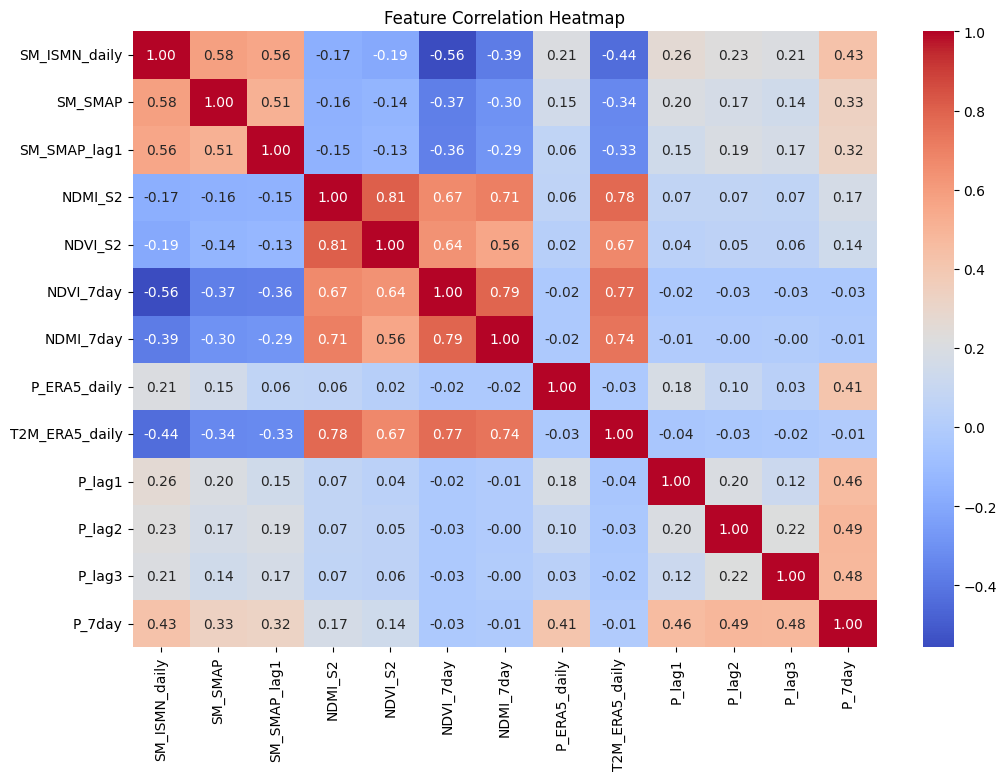

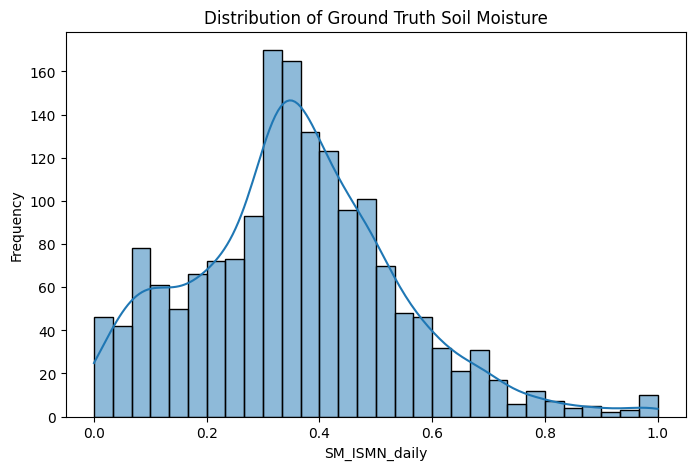

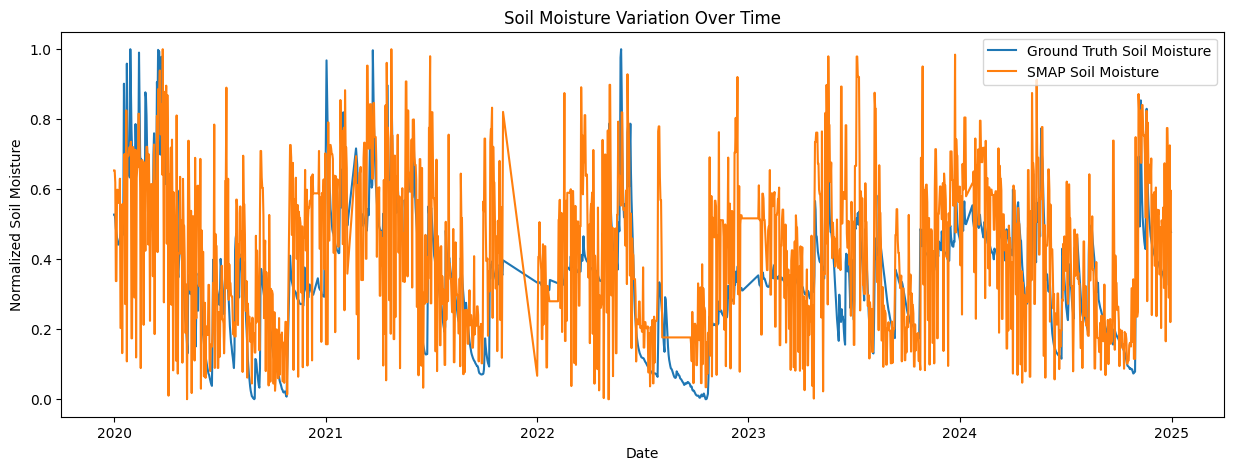

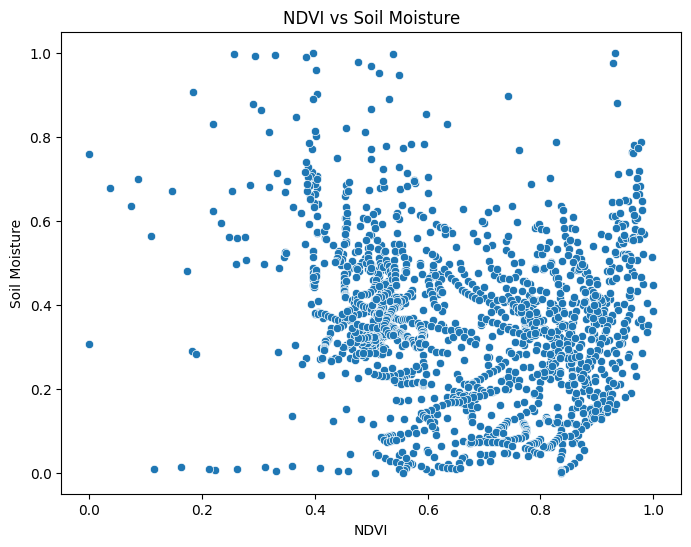

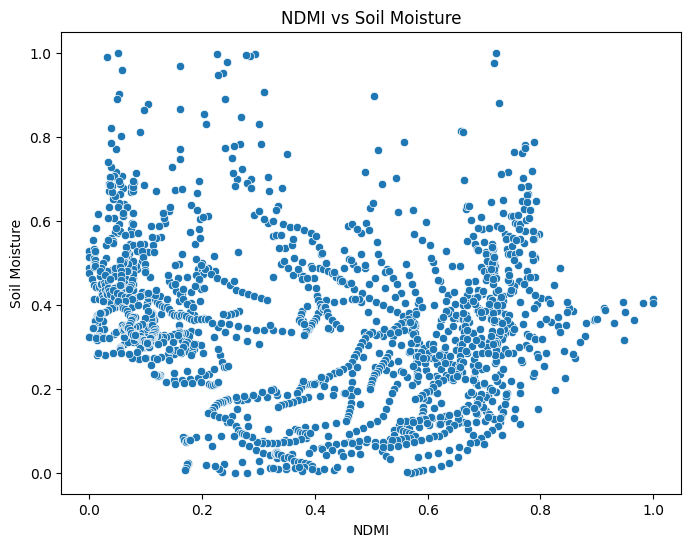

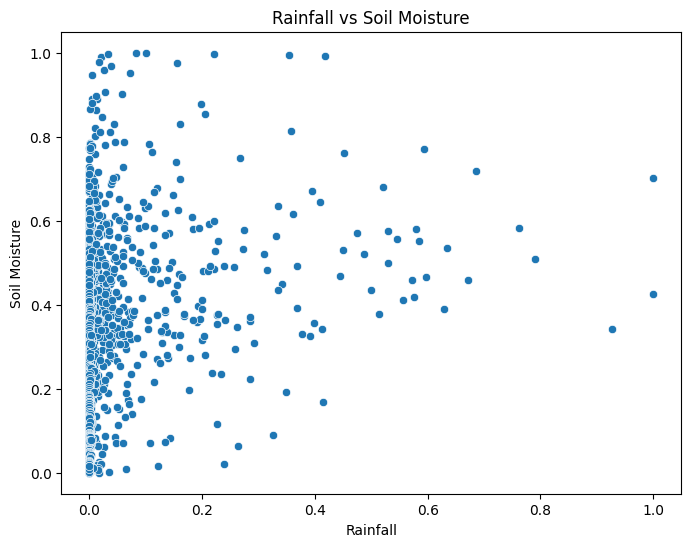

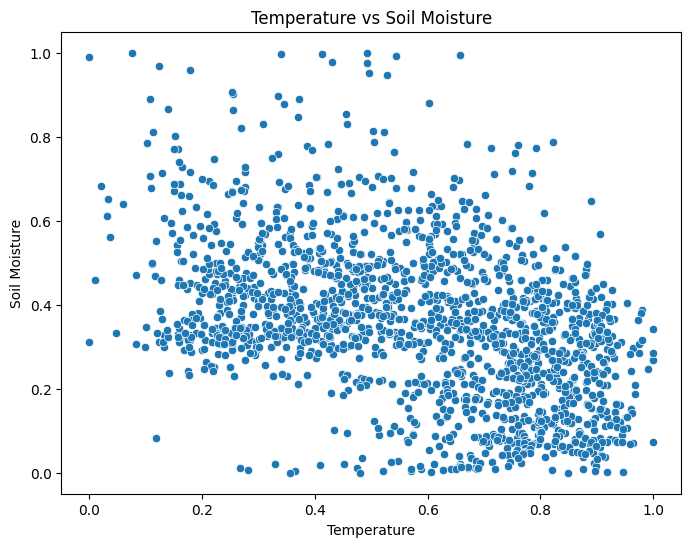


Feature Correlation with Soil Moisture
SM_ISMN_daily     1.000000
SM_SMAP           0.583177
SM_SMAP_lag1      0.559478
P_7day            0.426584
P_lag1            0.261958
P_lag2            0.226962
P_lag3            0.206366
P_ERA5_daily      0.205216
NDMI_S2          -0.168745
NDVI_S2          -0.194964
NDMI_7day        -0.385331
T2M_ERA5_daily   -0.440677
NDVI_7day        -0.557236
Name: SM_ISMN_daily, dtype: float64


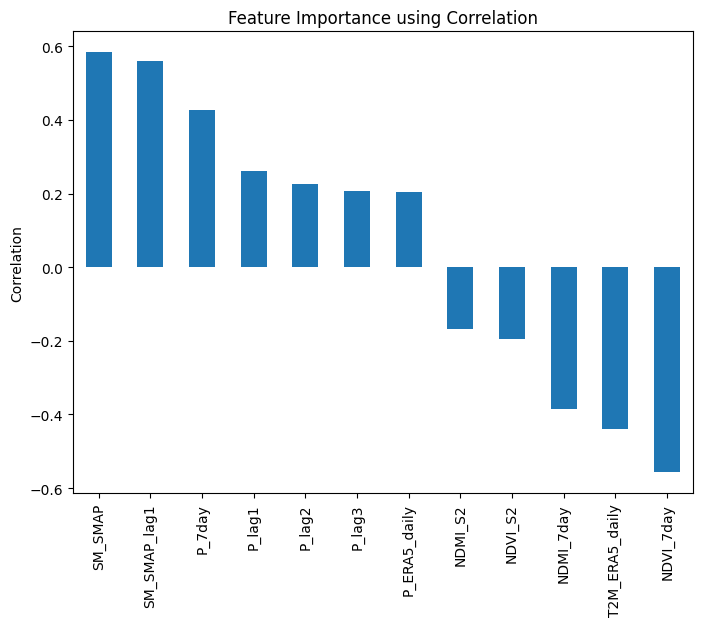

In [2]:
# ============================================
# SOIL MOISTURE DATASET ANALYSIS & VISUALIZATION
# ============================================

# Install if needed
# pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# --------------------------------------------
# LOAD DATASETS
# --------------------------------------------

df_2020 = pd.read_csv("fusion_training_table_2020_normalized.csv")
df_2021_2024 = pd.read_csv("fusion_training_table_2021_2024_normalized.csv")

# Merge datasets
df = pd.concat([df_2020, df_2021_2024], ignore_index=True)

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# --------------------------------------------
# BASIC DATASET ANALYSIS
# --------------------------------------------

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# --------------------------------------------
# CORRELATION ANALYSIS
# --------------------------------------------

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# --------------------------------------------
# SOIL MOISTURE DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df['SM_ISMN_daily'],
    bins=30,
    kde=True
)

plt.title("Distribution of Ground Truth Soil Moisture")
plt.xlabel("SM_ISMN_daily")
plt.ylabel("Frequency")
plt.show()

# --------------------------------------------
# TIME SERIES ANALYSIS
# --------------------------------------------

plt.figure(figsize=(15,5))

plt.plot(df['date'], df['SM_ISMN_daily'], label='Ground Truth Soil Moisture')
plt.plot(df['date'], df['SM_SMAP'], label='SMAP Soil Moisture')

plt.xlabel("Date")
plt.ylabel("Normalized Soil Moisture")
plt.title("Soil Moisture Variation Over Time")
plt.legend()
plt.show()

# --------------------------------------------
# NDVI vs SOIL MOISTURE
# --------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['NDVI_S2'],
    y=df['SM_ISMN_daily']
)

plt.title("NDVI vs Soil Moisture")
plt.xlabel("NDVI")
plt.ylabel("Soil Moisture")
plt.show()

# --------------------------------------------
# NDMI vs SOIL MOISTURE
# --------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['NDMI_S2'],
    y=df['SM_ISMN_daily']
)

plt.title("NDMI vs Soil Moisture")
plt.xlabel("NDMI")
plt.ylabel("Soil Moisture")
plt.show()

# --------------------------------------------
# RAINFALL EFFECT ANALYSIS
# --------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['P_ERA5_daily'],
    y=df['SM_ISMN_daily']
)

plt.title("Rainfall vs Soil Moisture")
plt.xlabel("Rainfall")
plt.ylabel("Soil Moisture")
plt.show()

# --------------------------------------------
# TEMPERATURE EFFECT ANALYSIS
# --------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['T2M_ERA5_daily'],
    y=df['SM_ISMN_daily']
)

plt.title("Temperature vs Soil Moisture")
plt.xlabel("Temperature")
plt.ylabel("Soil Moisture")
plt.show()

# --------------------------------------------
# FEATURE IMPORTANCE USING CORRELATION
# --------------------------------------------

target_corr = corr['SM_ISMN_daily'].sort_values(ascending=False)

print("\nFeature Correlation with Soil Moisture")
print(target_corr)

plt.figure(figsize=(8,6))

target_corr.drop('SM_ISMN_daily').plot(kind='bar')

plt.title("Feature Importance using Correlation")
plt.ylabel("Correlation")
plt.show()

## Model Preparation: Defining Features and Target

In [4]:
X = df.drop(['date', 'SM_ISMN_daily'], axis=1)
y = df['SM_ISMN_daily']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display first few rows of features
print("\nFirst 5 Rows of Features (X):")
print(X.head())

Features (X) shape: (1682, 12)
Target (y) shape: (1682,)

First 5 Rows of Features (X):
    SM_SMAP  SM_SMAP_lag1  NDMI_S2   NDVI_S2  NDVI_7day  NDMI_7day  \
0  0.653687      0.653687      0.0  0.396278        0.0   0.014187   
1  0.653687      0.653687      0.0  0.396278        0.0   0.014187   
2  0.619134      0.653687      0.0  0.396278        0.0   0.014187   
3  0.337482      0.619134      0.0  0.396278        0.0   0.014187   
4  0.337482      0.337482      0.0  0.396278        0.0   0.014187   

   P_ERA5_daily  T2M_ERA5_daily    P_lag1    P_lag2    P_lag3    P_7day  
0      0.000007        0.241676  0.000007  0.000007  0.000007  0.000099  
1      0.000016        0.340968  0.000007  0.000007  0.000007  0.000099  
2      0.000168        0.275438  0.000016  0.000007  0.000007  0.000099  
3      0.000029        0.186733  0.000168  0.000016  0.000007  0.000099  
4      0.000015        0.276945  0.000029  0.000168  0.000016  0.000099  


## Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1345, 12)
X_test shape: (337, 12)
y_train shape: (1345,)
y_test shape: (337,)


## Model Training and Prediction (Linear Regression)

In [6]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete. Predictions generated.")

Model training complete. Predictions generated.


MAE : 0.09116095971709536
RMSE: 0.1161017676635532
R2 Score: 0.6319695581510439


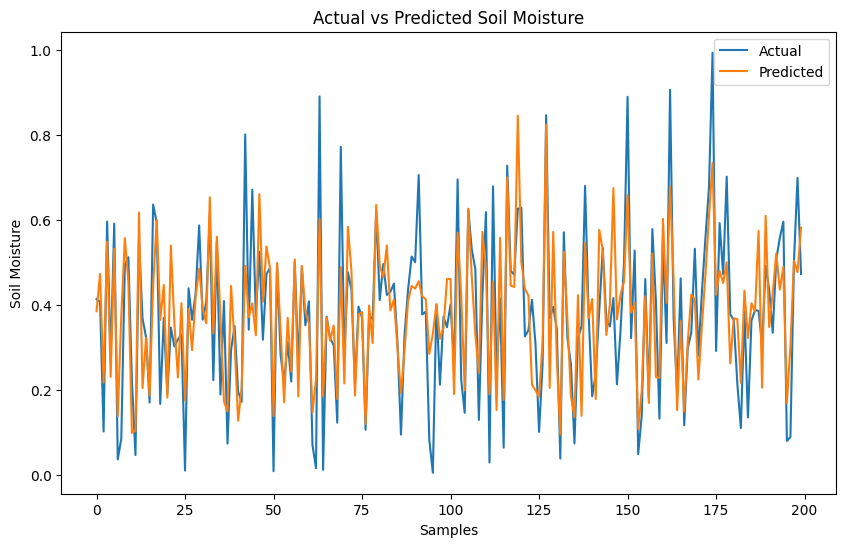

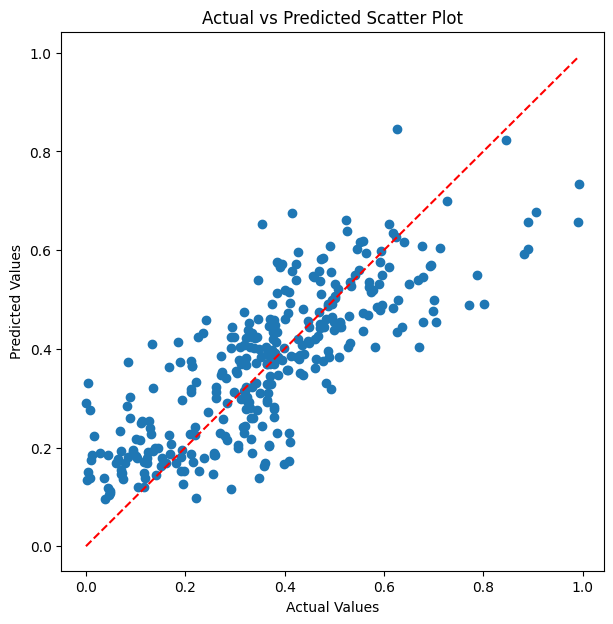

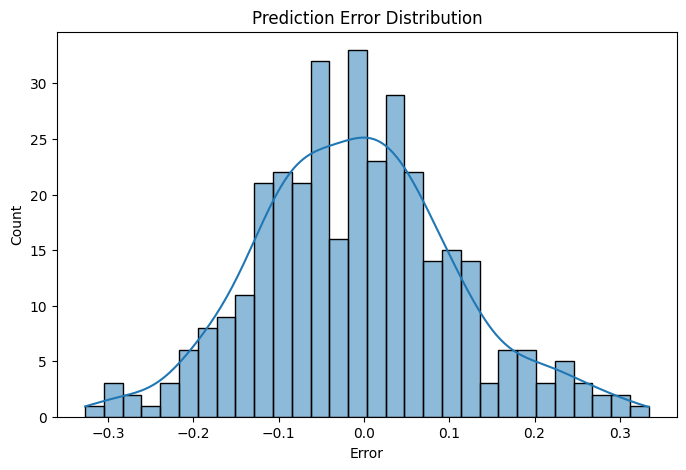

In [7]:
# ============================================
# MODEL PERFORMANCE ANALYSIS
# ============================================

# y_test -> actual values
# y_pred -> predicted values

# Example:
# y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# --------------------------------------------
# ACTUAL vs PREDICTED PLOT
# --------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(y_test[:200].reset_index(drop=True), label='Actual') # Reset index for plotting
plt.plot(y_pred[:200], label='Predicted')

plt.title("Actual vs Predicted Soil Moisture")
plt.xlabel("Samples")
plt.ylabel("Soil Moisture")
plt.legend()
plt.show()

# --------------------------------------------
# SCATTER PLOT
# --------------------------------------------

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

# --------------------------------------------
# ERROR DISTRIBUTION
# --------------------------------------------

errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

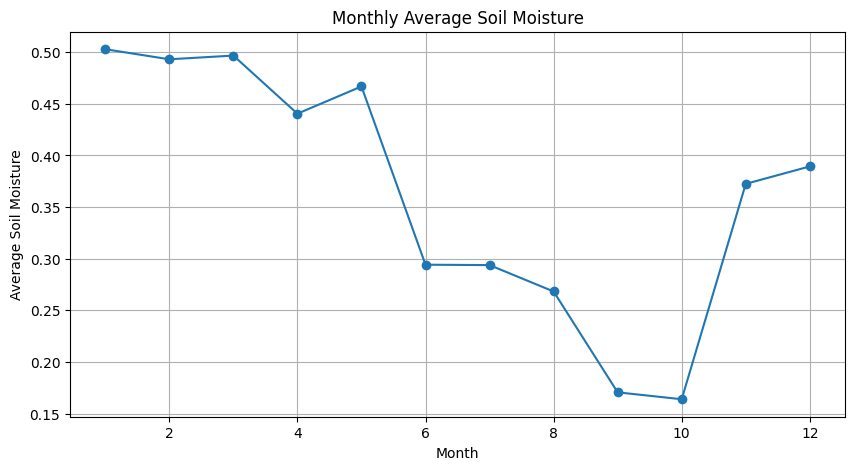

In [8]:
# ============================================
# MONTHLY SOIL MOISTURE ANALYSIS
# ============================================

df['month'] = df['date'].dt.month

monthly_sm = df.groupby('month')['SM_ISMN_daily'].mean()

plt.figure(figsize=(10,5))

monthly_sm.plot(marker='o')

plt.title("Monthly Average Soil Moisture")
plt.xlabel("Month")
plt.ylabel("Average Soil Moisture")
plt.grid(True)
plt.show()

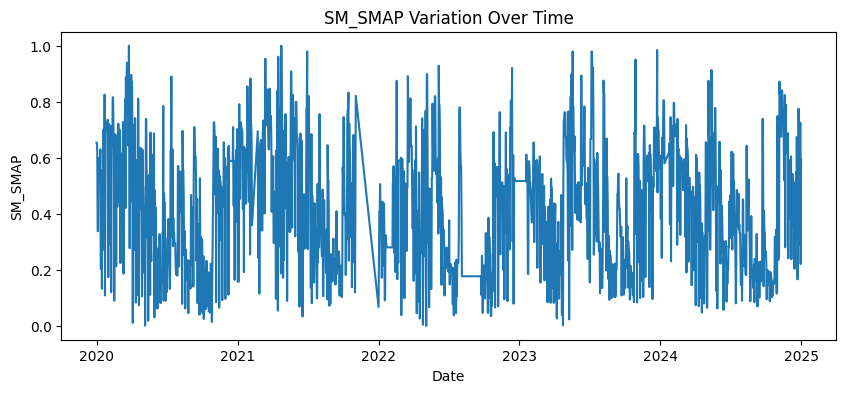

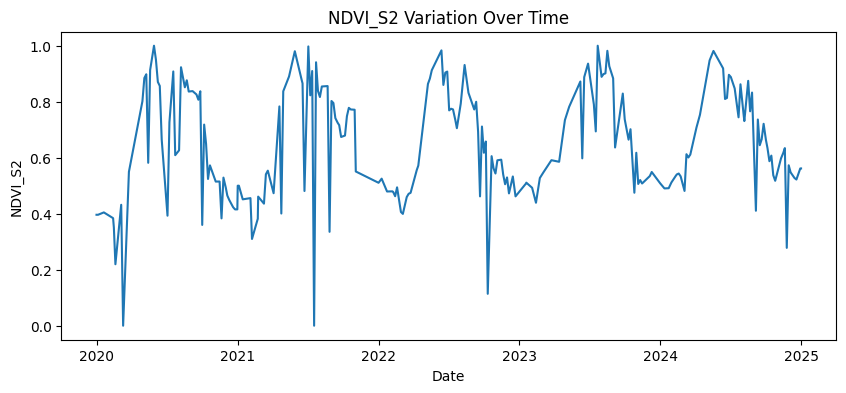

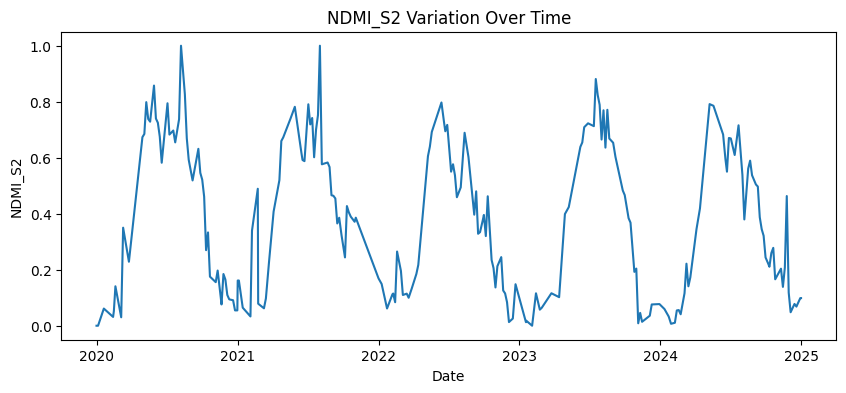

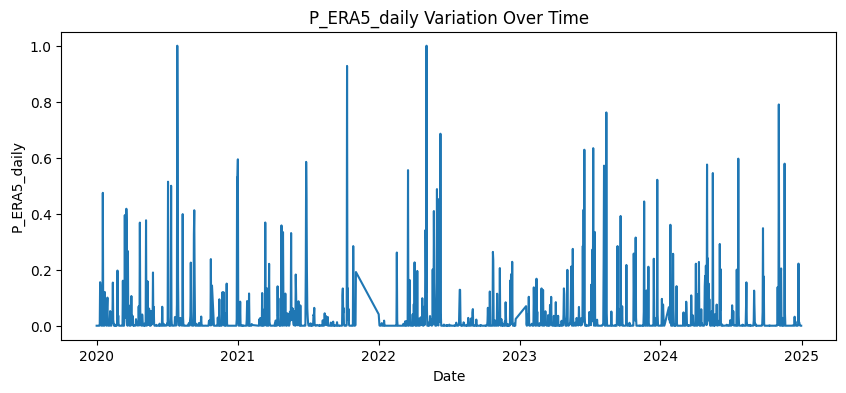

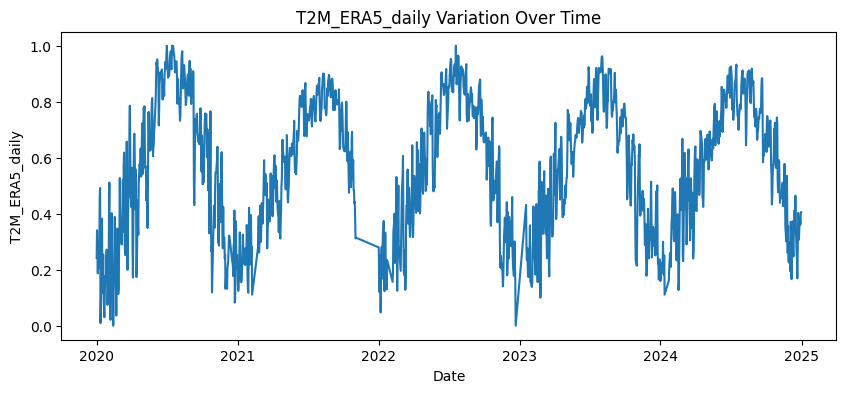

In [9]:
features = [
    'SM_SMAP',
    'NDVI_S2',
    'NDMI_S2',
    'P_ERA5_daily',
    'T2M_ERA5_daily'
]

for feature in features:

    plt.figure(figsize=(10,4))

    plt.plot(df['date'], df[feature])

    plt.title(f"{feature} Variation Over Time")
    plt.xlabel("Date")
    plt.ylabel(feature)

    plt.show()

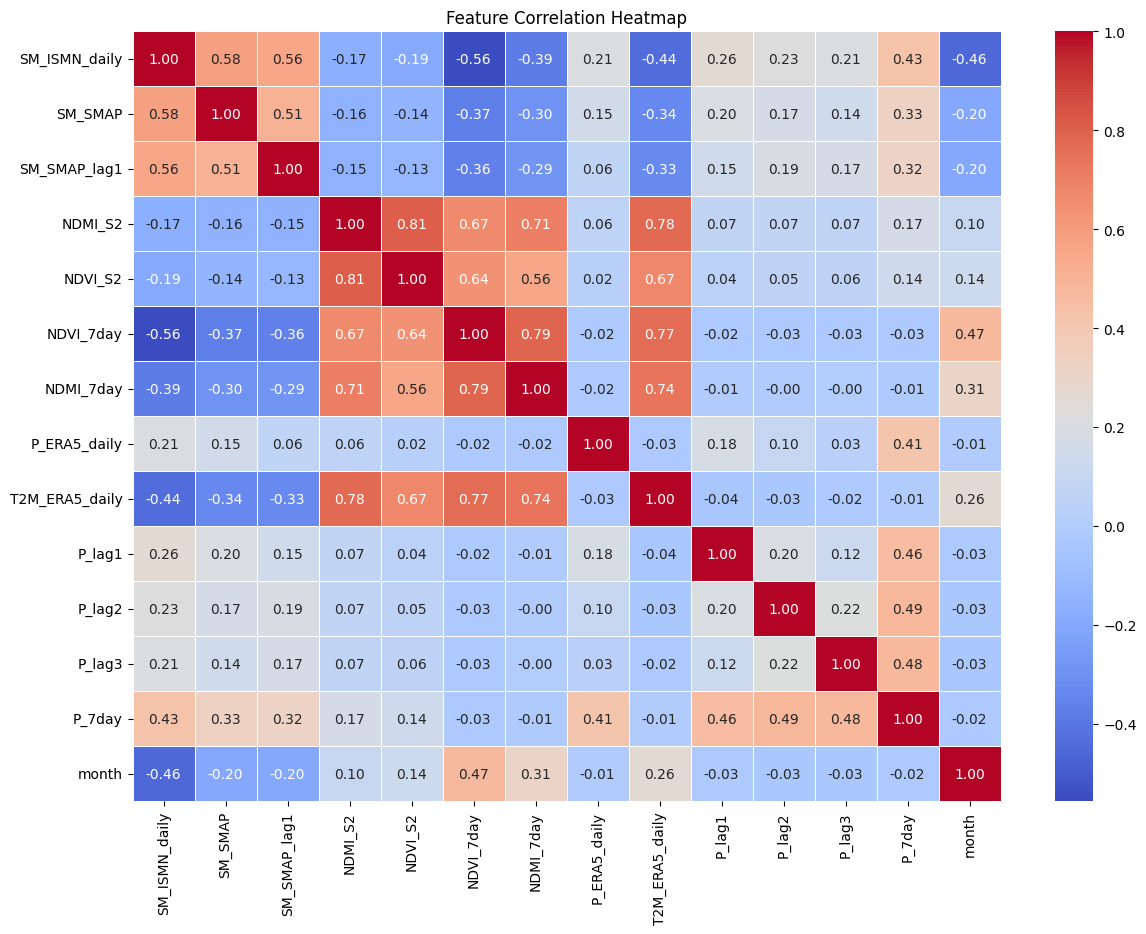

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

           Feature  Importance
4        NDVI_7day    0.382263
0          SM_SMAP    0.120332
5        NDMI_7day    0.117089
11          P_7day    0.110141
1     SM_SMAP_lag1    0.081986
3          NDVI_S2    0.053568
2          NDMI_S2    0.042360
7   T2M_ERA5_daily    0.025525
8           P_lag1    0.022198
6     P_ERA5_daily    0.016838
10          P_lag3    0.016412
9           P_lag2    0.011288


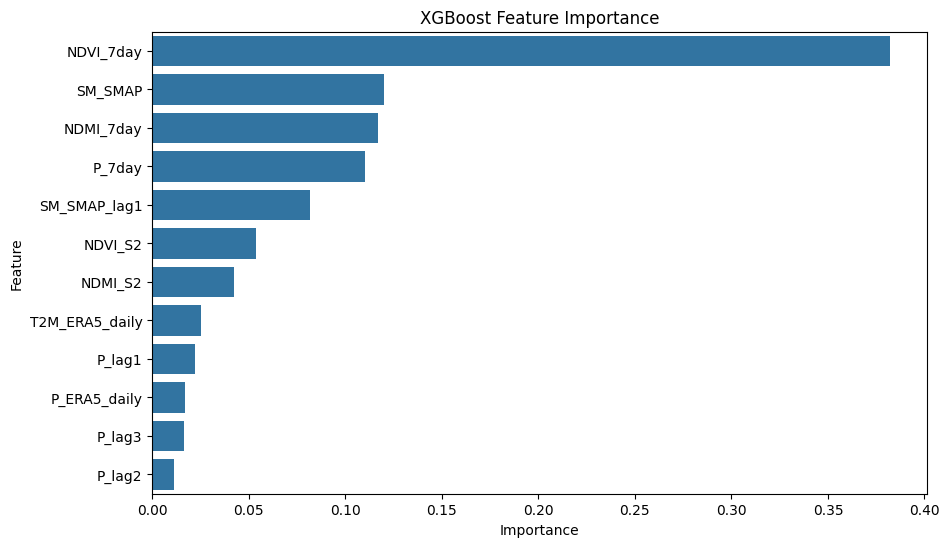

In [11]:
from xgboost import XGBRegressor

# Train XGBoost
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("XGBoost Feature Importance")
plt.show()

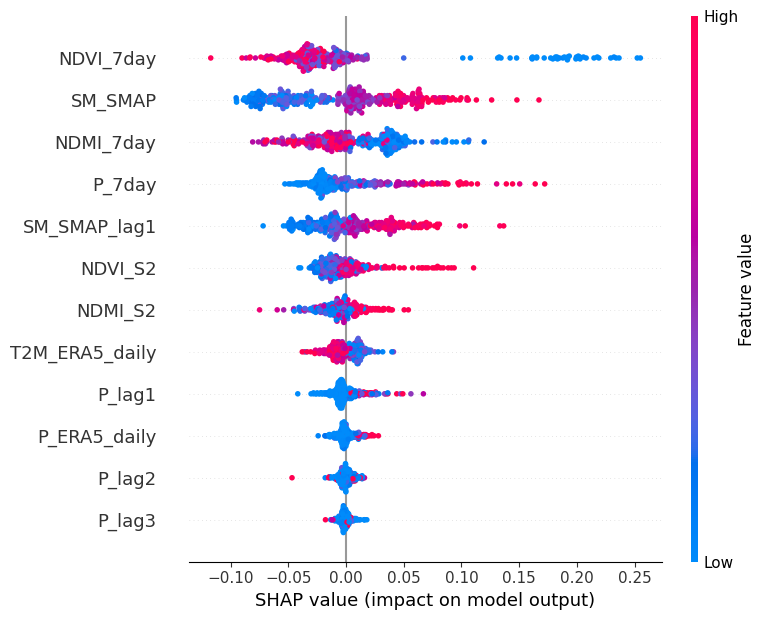

In [12]:
import shap

explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test)

# Summary Plot
shap.summary_plot(
    shap_values,
    X_test
)

In [13]:
from sklearn.metrics import r2_score

baseline_model = XGBRegressor()
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline R2:", baseline_r2)

results = []

for feature in X_train.columns:

    X_train_new = X_train.drop(columns=[feature])
    X_test_new = X_test.drop(columns=[feature])

    model = XGBRegressor()

    model.fit(X_train_new, y_train)

    pred = model.predict(X_test_new)

    r2 = r2_score(y_test, pred)

    delta_r2 = baseline_r2 - r2

    results.append([feature, r2, delta_r2])

ablation_df = pd.DataFrame(
    results,
    columns=['Removed Feature', 'R2', 'Delta_R2']
)

ablation_df = ablation_df.sort_values(
    by='Delta_R2',
    ascending=False
)

print(ablation_df)

Baseline R2: 0.843518373717652
   Removed Feature        R2  Delta_R2
11          P_7day  0.788928  0.054590
4        NDVI_7day  0.825403  0.018115
2          NDMI_S2  0.831043  0.012476
5        NDMI_7day  0.832458  0.011061
7   T2M_ERA5_daily  0.840371  0.003147
1     SM_SMAP_lag1  0.840536  0.002983
10          P_lag3  0.847035 -0.003517
6     P_ERA5_daily  0.849488 -0.005970
9           P_lag2  0.851243 -0.007725
3          NDVI_S2  0.852549 -0.009030
8           P_lag1  0.857570 -0.014051
0          SM_SMAP  0.864368 -0.020850


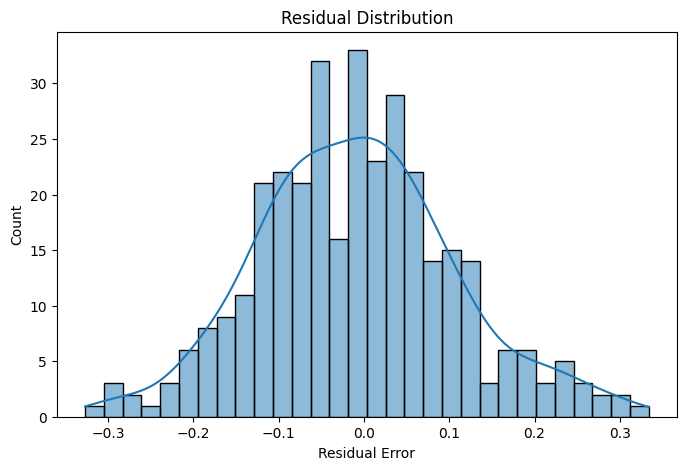

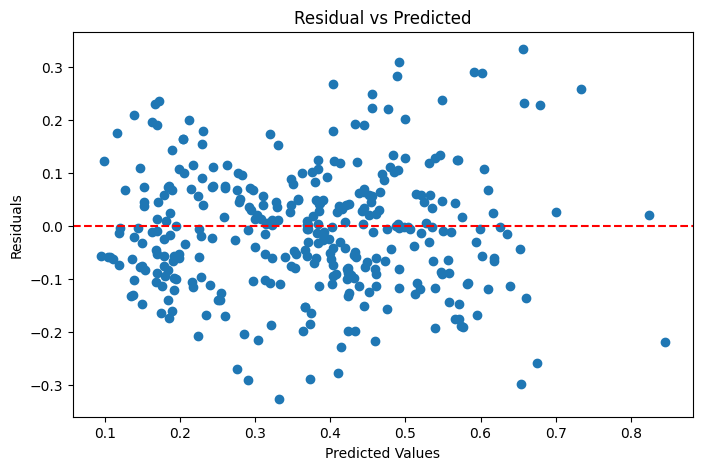

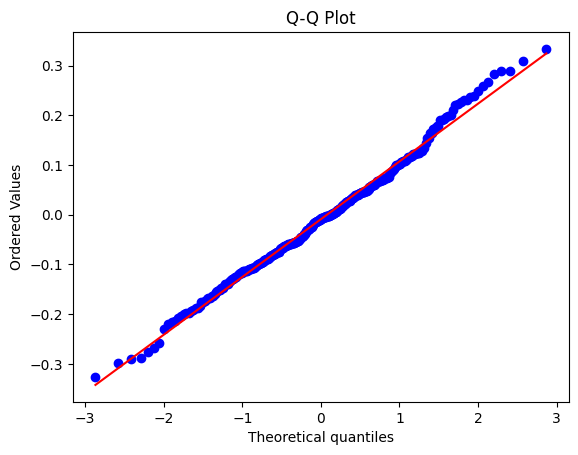

In [14]:
import scipy.stats as stats

residuals = y_test - y_pred

# Residual histogram
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual Error")
plt.show()

# Residual vs Predicted
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='r',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Predicted")
plt.show()

# QQ Plot
stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

models = {
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(), # xgb_model is already defined and trained from a previous cell
    "MLP": MLPRegressor(hidden_layer_sizes=(128,64,32))
}

results = []

# Instantiate and train RandomForestRegressor and MLPRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# XGBoost model is already trained as xgb_model in a previous cell (KWDRx7ZMxgD)
# If it wasn't, you would train it here:
# xgb_model = XGBRegressor()
# xgb_model.fit(X_train, y_train)

mlp_model = MLPRegressor(hidden_layer_sizes=(128,64,32), random_state=42, max_iter=500)
mlp_model.fit(X_train, y_train)

# Collect results for all models
# For Random Forest
rf_pred = rf_model.predict(X_test)
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
results.append(["Random Forest", r2_rf, rmse_rf, mae_rf])

# For XGBoost (using the already trained xgb_model)
xgb_pred_comp = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, xgb_pred_comp)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred_comp))
mae_xgb = mean_absolute_error(y_test, xgb_pred_comp)
results.append(["XGBoost", r2_xgb, rmse_xgb, mae_xgb])

# For MLP
mlp_pred = mlp_model.predict(X_test)
r2_mlp = r2_score(y_test, mlp_pred)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_pred))
mae_mlp = mean_absolute_error(y_test, mlp_pred)
results.append(["MLP", r2_mlp, rmse_mlp, mae_mlp])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'R2', 'RMSE', 'MAE']
)

print(results_df)

           Model        R2      RMSE       MAE
0  Random Forest  0.823151  0.080482  0.057821
1        XGBoost  0.843518  0.075706  0.056053
2            MLP  0.743604  0.096906  0.075883


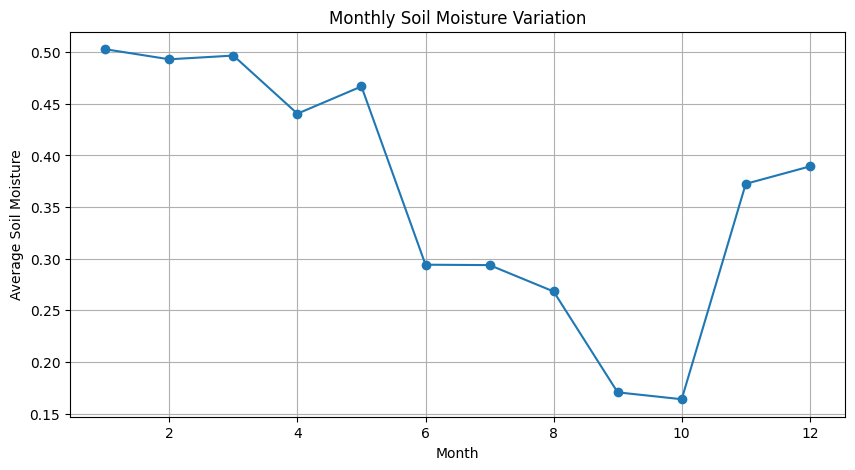

In [16]:
df['month'] = pd.to_datetime(df['date']).dt.month

monthly_sm = df.groupby('month')['SM_ISMN_daily'].mean()

plt.figure(figsize=(10,5))

monthly_sm.plot(
    marker='o'
)

plt.title("Monthly Soil Moisture Variation")
plt.xlabel("Month")
plt.ylabel("Average Soil Moisture")
plt.grid(True)

plt.show()

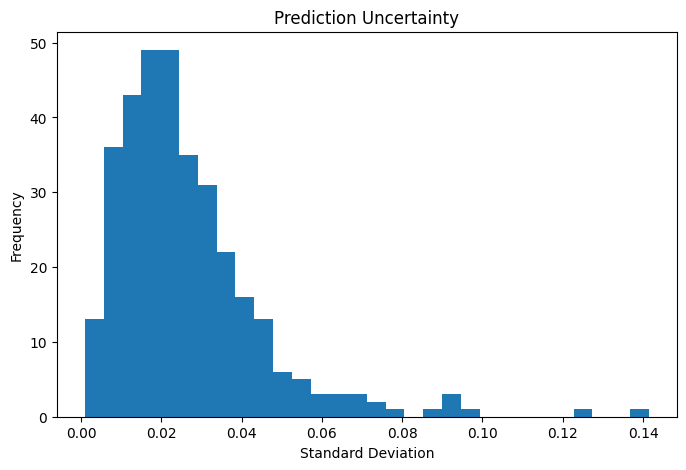

In [21]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
mlp_pred = mlp_model.predict(X_test)

predictions = np.vstack([
    rf_pred,
    xgb_pred,
    mlp_pred
])

uncertainty = np.std(
    predictions,
    axis=0
)

plt.figure(figsize=(8,5))

plt.hist(
    uncertainty,
    bins=30
)

plt.title("Prediction Uncertainty")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

plt.show()

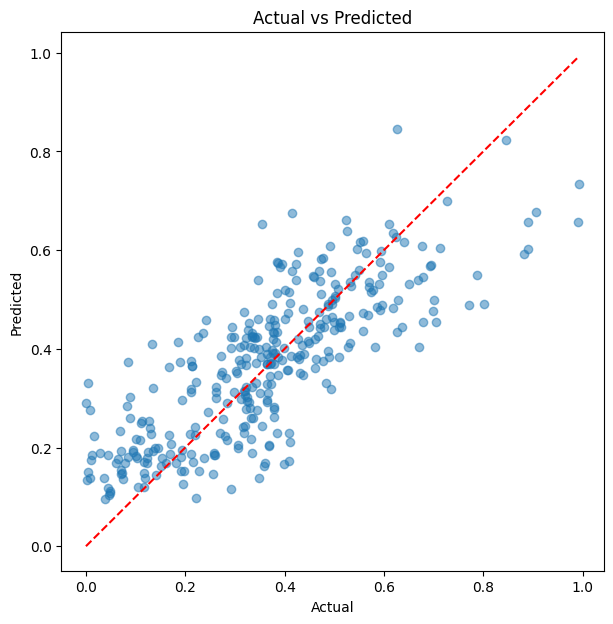

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

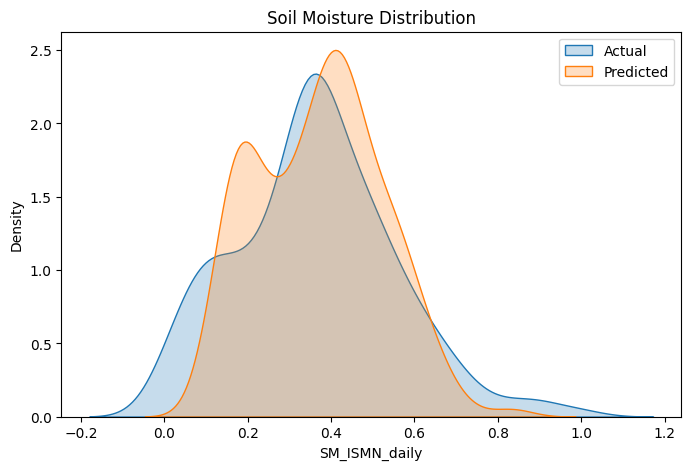

In [24]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    y_test,
    label='Actual',
    fill=True
)

sns.kdeplot(
    y_pred,
    label='Predicted',
    fill=True
)

plt.title("Soil Moisture Distribution")

plt.legend()

plt.show()

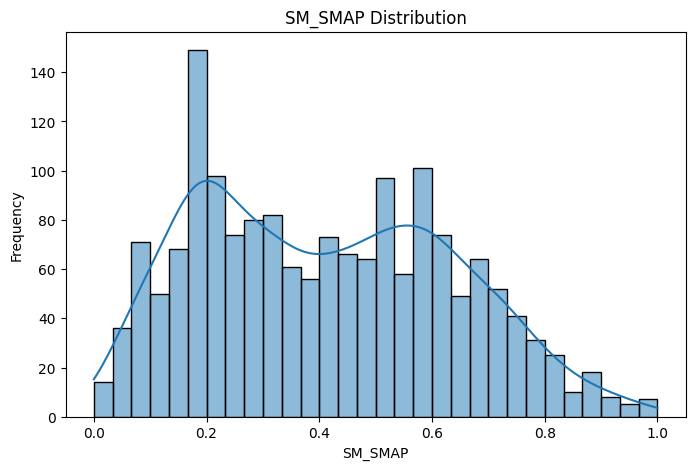

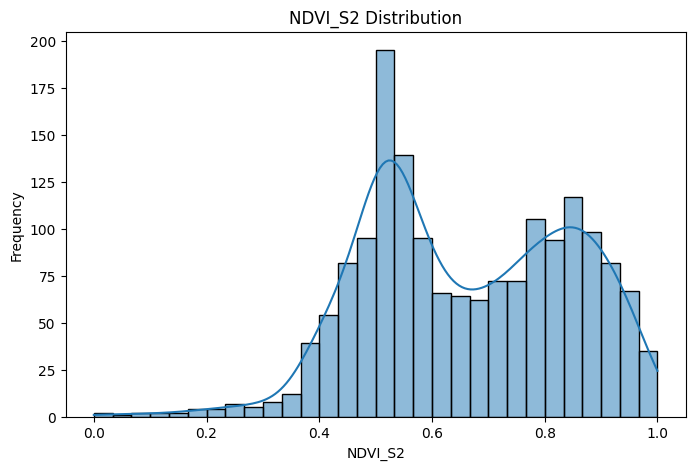

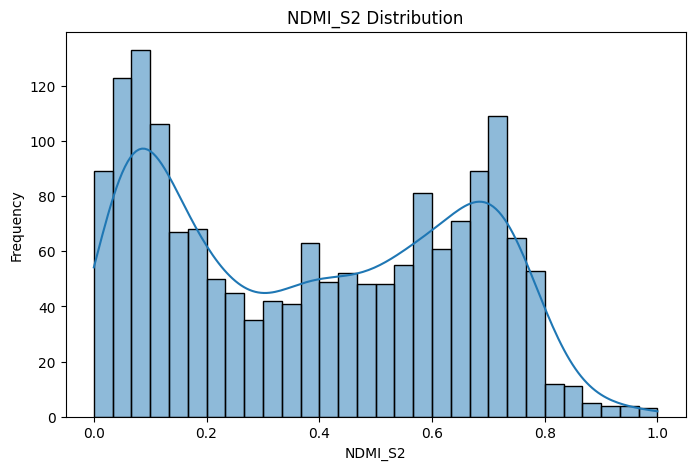

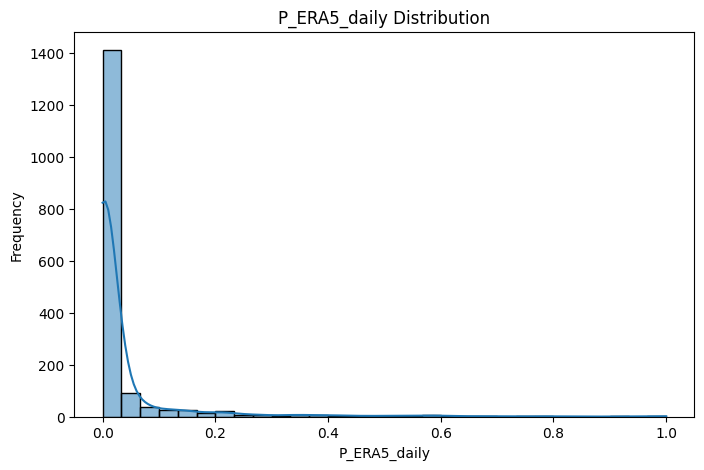

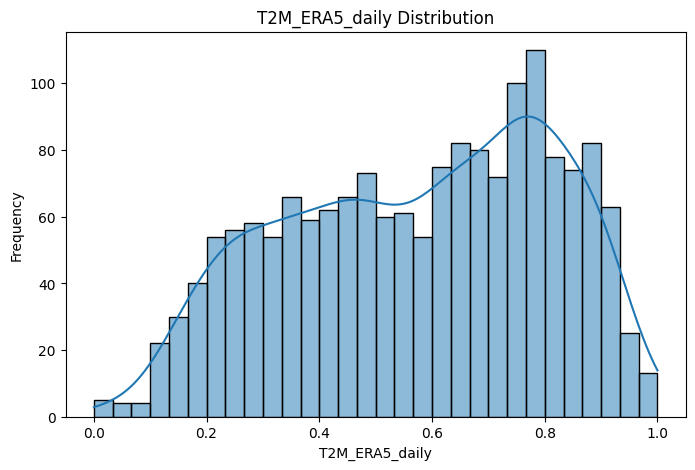

In [26]:
fusion_features = [
    'SM_SMAP',
    'NDVI_S2',
    'NDMI_S2',
    'P_ERA5_daily',
    'T2M_ERA5_daily'
]

for feature in fusion_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[feature],
        bins=30,
        kde=True
    )

    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

        Source  Contribution
0         SMAP      0.583177
1   Vegetation      0.181854
2  Meteorology      0.322946


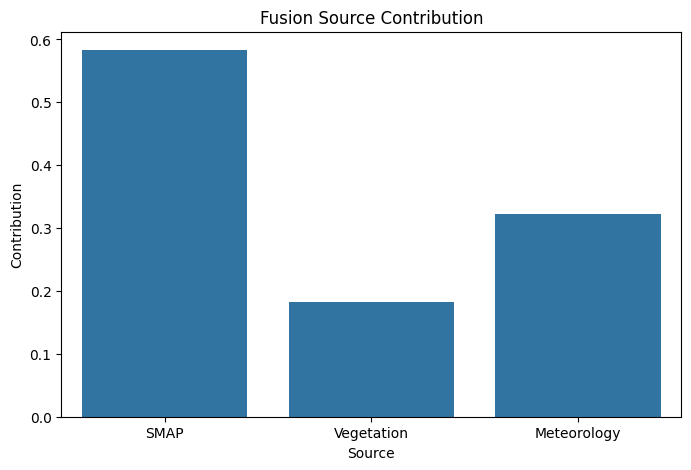

In [28]:
source_groups = {
    "SMAP": ['SM_SMAP'],
    "Vegetation": ['NDVI_S2', 'NDMI_S2'],
    "Meteorology": ['P_ERA5_daily', 'T2M_ERA5_daily']
}

correlations = {}

for group, cols in source_groups.items():

    mean_corr = np.mean([
        abs(df[col].corr(df['SM_ISMN_daily']))
        for col in cols
    ])

    correlations[group] = mean_corr

group_df = pd.DataFrame({
    'Source': correlations.keys(),
    'Contribution': correlations.values()
})

print(group_df)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Source',
    y='Contribution',
    data=group_df
)

plt.title("Fusion Source Contribution")

plt.show()

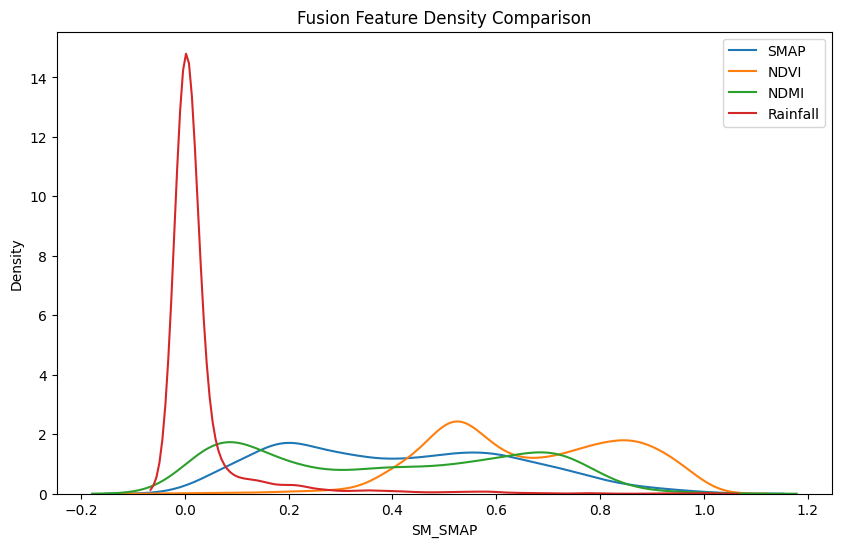

In [29]:
plt.figure(figsize=(10,6))

sns.kdeplot(df['SM_SMAP'], label='SMAP')
sns.kdeplot(df['NDVI_S2'], label='NDVI')
sns.kdeplot(df['NDMI_S2'], label='NDMI')
sns.kdeplot(df['P_ERA5_daily'], label='Rainfall')

plt.title("Fusion Feature Density Comparison")

plt.legend()

plt.show()

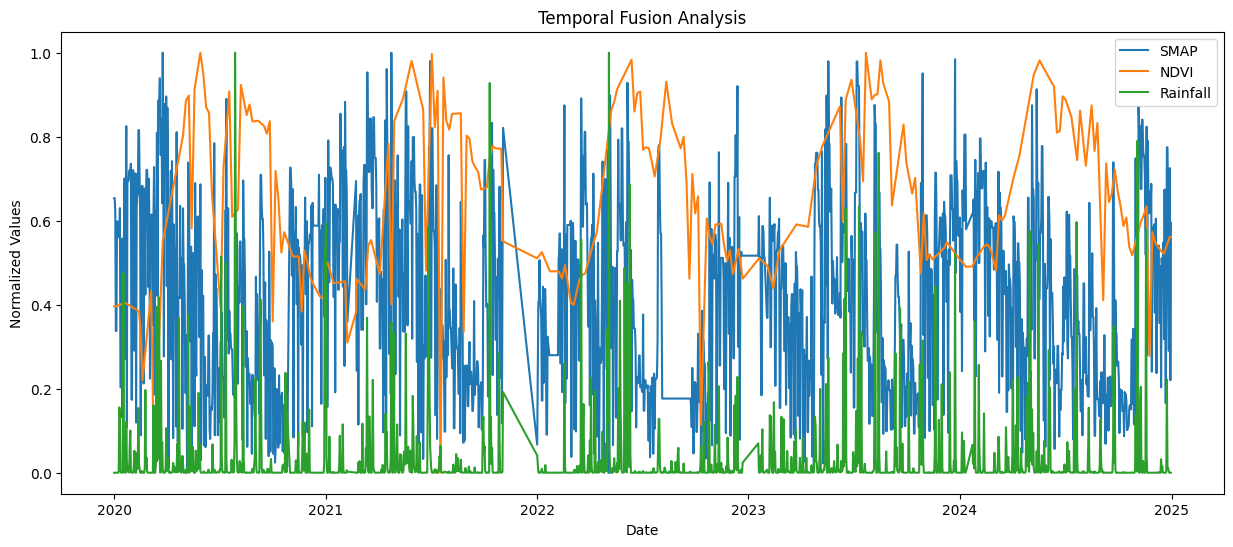

In [30]:
plt.figure(figsize=(15,6))

plt.plot(df['date'], df['SM_SMAP'], label='SMAP')
plt.plot(df['date'], df['NDVI_S2'], label='NDVI')
plt.plot(df['date'], df['P_ERA5_daily'], label='Rainfall')

plt.legend()

plt.title("Temporal Fusion Analysis")

plt.xlabel("Date")
plt.ylabel("Normalized Values")

plt.show()

In [31]:
for feature in fusion_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ]

    print(f"{feature} Outliers:", len(outliers))

SM_SMAP Outliers: 0
NDVI_S2 Outliers: 3
NDMI_S2 Outliers: 0
P_ERA5_daily Outliers: 293
T2M_ERA5_daily Outliers: 0


NDMI_S2           0.262655
T2M_ERA5_daily    0.233825
SM_SMAP           0.225244
NDVI_S2           0.182764
P_ERA5_daily      0.096941
dtype: float64


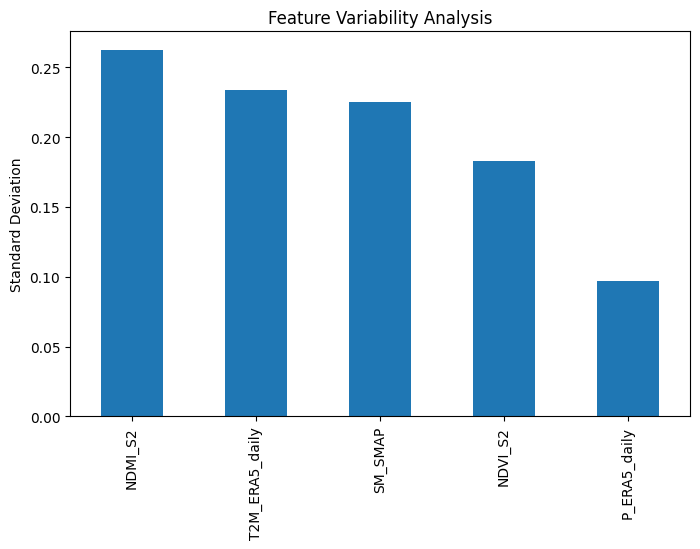

In [32]:
variability = df[fusion_features].std()

variability = variability.sort_values(
    ascending=False
)

print(variability)

plt.figure(figsize=(8,5))

variability.plot(kind='bar')

plt.title("Feature Variability Analysis")

plt.ylabel("Standard Deviation")

plt.show()

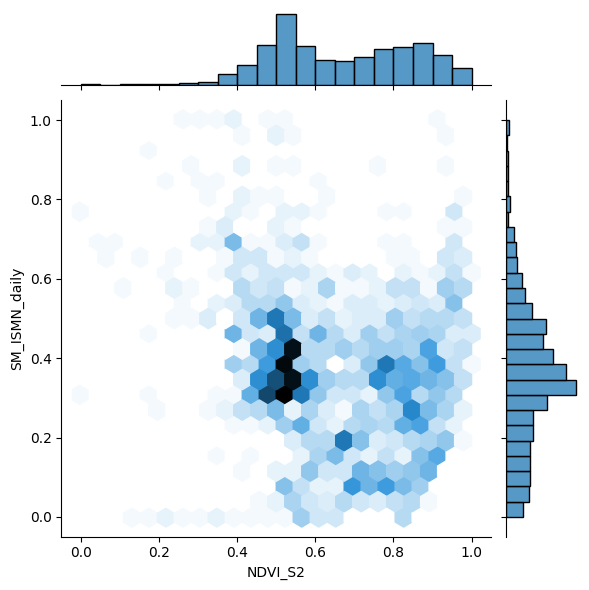

In [33]:
sns.jointplot(
    x=df['NDVI_S2'],
    y=df['SM_ISMN_daily'],
    kind='hex'
)

plt.show()

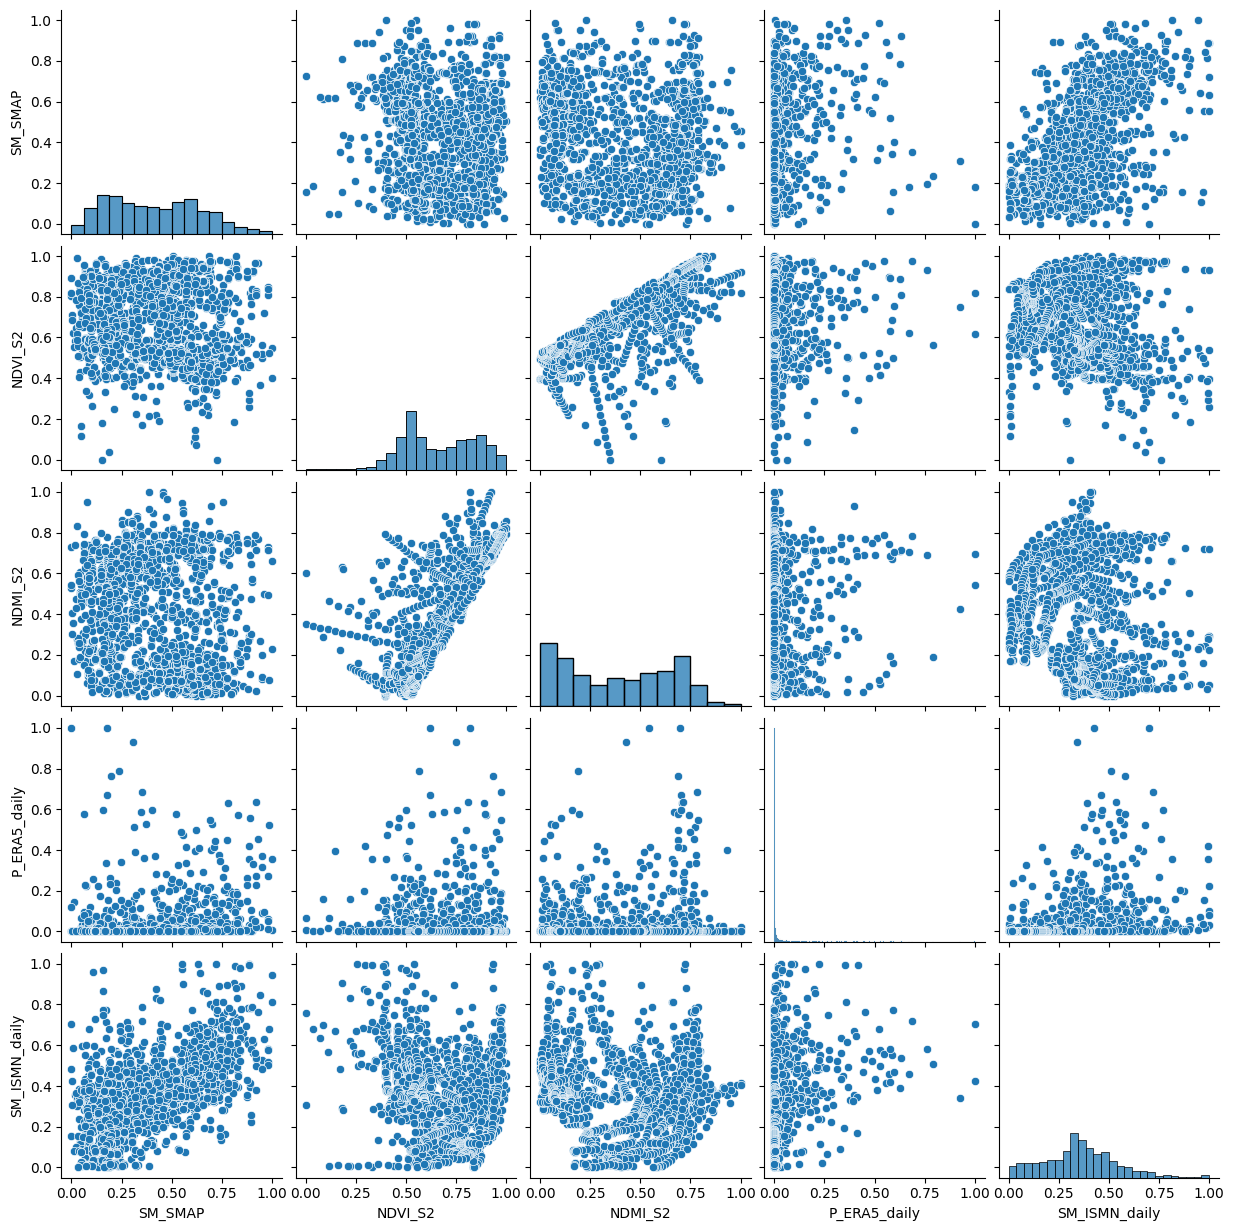

In [34]:
pair_cols = [
    'SM_SMAP',
    'NDVI_S2',
    'NDMI_S2',
    'P_ERA5_daily',
    'SM_ISMN_daily'
]

sns.pairplot(df[pair_cols])

plt.show()